# McDonald Valley Exercise

In this problem, we've designed a hypothetical field problem that parallels the model construction and calibration process much like a real field problem. This exercise is intended to give the student experience in building a flow model from GIS data sets and performing some hand calibration on that flow model.

This problem will be approached in 3 - 4 stages depending on time:

**Stage 1**: Review the included information and project objectives to design an effective approach to simulating the system. In this stage you may want to consider the pros and cons of various boundary conditions, discretization schemes, etc...

**Stage 2** Develop a model for the predevelopment condition based on the existing data that are provided to you

**Stage 3** Calibrate the model using "hand calibration" techniques. *Note* we will give you an example of how to update an existing boundary condition with FloPy

**Stage 4** Simulate the effects of the proposed stresses on the system using the calibrated model from stage 3.


### Stage 1: Problem formulation and existing data:
**Background**

McDonald Valley is an undeveloped, closed alluvial valley surrounded by low permeability crystalline bedrock (figures 1 and 2). The valley is dominated by scenic Lake Harbaugh located in the northwest corner of the valley (lots are available). Lake Harbaugh sits in a gentle depression that is bounded by Sand Ridge, which extends from the western edge of the valley to the northeastern corner. The south face of Sand Ridge is relatively steep. South of Sand Ridge, the valley slopes gently toward the southern boundary. The Straight River, which has its headwaters at the base of sand ridge just south of Lake Harbaugh, flows south and eventually leaves the valley along the southern boundary.

You have been given the task of examining the possible effects of groundwater development that has been proposed for McDonald Valley. The following development has been proposed:
   1. A 268,000 ft3/d well in the southern part of the valley at either site 1 or site 2 as shown in figure 2. The well would provide a water supply for Virginia City located to the south of McDonald Valley.
   2. A 67,000 ft3/d well is located in the northern part of the valley (site 3 in figure 2). This well would provide natural spring water for Reilly's Premium Beverages, Inc.

The county is concerned about the effect of this development. Specifically,the county is concerned that:

   1. Development will cause excessive water table declines in the northern half of the valley where a number of summer homes have very shallow water table wells that are used for domestic supply. The county has established the requirement that any development not cause more than a 2 foot decline in the water table anywhere in the northern half of the valley. Consultants for the Reilly Brewing Company contend that pumping from the Reilly well will have a negligible effect on the water table because the well will be placed below a clay layer that occurs across much of the northern part of the valley.
   2. McDonald Valley is the site of the Pollock's Ford National Historic Site and Recreation Area located 1000 feet south of the headwaters of the Straight River. Pollock's Ford is the site of an heroic fording of the Straight River during the battle for Sand Ridge during the American Revolution. Even though easier routes around the north side of the headwaters were discovered within minutes of Pollock's heroic crossing, the event nevertheless remains one of extreme historic importance. The county maintains a stream gage at Pollock's Ford and has decided that any potential development by Virginia City or Reilly's Brewery must not reduce the stream flow at that site by more than 20 percent. In addition, the county is requiring that development not lead to any induced infiltration from the Straight River anywhere along its course.
   3. The county is requiring stream capture analysis for the proposed well sites.



**The study area**

McDonald valley encompasses an area of about $2.4 * 10^8 ft^2$ and is shown in the figures below

![maps](../data/class_project/combined_map.png)


**Hydrogeology**

The valley contains unconsolidated valley fill alluvium. No hydraulic tests have been performed in the valley, but the sediments are similar to those in other valleys in the area which generally have horizontal hydraulic conductivities ranging between 10 feet/day and 500 feet/day. The sediments are predominantly medium to coarse grained sands and some gravels, however a low permeability lake clay has been observed in some bore holes in the valley. A hydrogeologic framework has already been constructed for the valley sediments, and hydraulic conductivity estimates and layering has been provided by the geologists. These datasets are in raster format.

**Hydrology**

The hydrologic system in McDonald Valley is in steady state with no significant seasonal or short term fluctuations in conditions.

McDonald Valley has a **mean annual precipitation of 36 inches per year** based on measurements made at Lake Harbaugh. Other stations in the area also report annual precipitation of 36 inches per year.

There is no surface water inflow into the valley. The Straight River originates in McDonald Valley. The headwaters of the river is located 9000 feet upstream from the southern boundary of the valley. The **river stage at the southern boundary of the valley is defined to be 0**, the datum to which all other head measurements in the valley are referenced. **The stream gradient is 0.0002, which corresponds to a stage of 1.8 feet at the headwaters**. The **river is approximately 100 feet wide over its entire length and has a depth of 1 foot or less** in most locations. Stream gages are located at the river's southern discharge point and at Pollock's Ford.

*Measured streamflow*
   - Southern Boundary: 884,494 $ft^3/d$
   - Pollock's Ford: 96,402 $ft^3/d$

*Lake Harbaugh information*

Lake Harbaugh is a dominant hydrologic feature in the valley. A previous study of Lake Harbaugh yielded the following information:
   - Stage: 11 ft
   - Lake evaporation: 27 inches per year
   - Precipitaiton: 36 inches per year
   - Estimated area of the lake is: $1.625 * 10^7 ft^2 $ : A lake delineation was done with GIS and that data is stored in a shapefile (*hint: you will need to get the area of the lake from it later*)

Lake Harbaugh is a closed lake with no surface water inflow or outflow. The morphology of the lake basin consists of a relatively steep sloping shore that levels out to a very uniform depth of 16 feet within 50 feet of the lake shore. The lake bottom is sandy and free of fine grained sediments over most of its bottom, especially near the shore. Very minor amounts of fine grained sediments occur in the very center of the lake basin.

**Water table elevations**

The previous field study also sampled 17 wells throughout McDonald Valley and recorded water levels. These water level elevations (at the water table) are shown below and have been stored in a shapefile too.

![Water_levels](../data/class_project/water_table_elevations.png)

### Problem formulation
**Study Questions**
Take a few minutes to think through these questions and come up with a conceptual model of McDonald Valley.

   1. Describe the elements of the hydrology of the system that you believe will be the most important in your analysis

   2. Describe how you would treat the boundary conditions and stresses

   3. Think about how you would incorporate the effects of the lake and river into this model? How will you simulate them and with which package(s)

   4. Write a water budget for the lake given the information that you have. Is the lake a net source or sink of water for the groundwater system? Can you make a quantitative estimate of the net rate of groundwater recharge or discharge due to the lake.

   5. What is the total amount of recharge to McDonald Valley and how is it distributed?

### Stage 2: Develop a model that represents pre-development conditions

For each step in the model development process shapefile and raster data that you'll need will be listed for the step. Examples and "recipies" from the previous notebooks can and should be used to help process data and build the MODFLOW model. Our first step here is importing the required python packages for this project.

In [7]:
import flopy
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

from flopy.discretization import StructuredGrid, VertexGrid
from flopy.utils.triangle import Triangle
from flopy.utils.voronoi import VoronoiGrid

from flopy.utils import GridIntersect, Raster
import matplotlib.pyplot as plt

# define the data_ws
data_ws = Path("../data/class_project")

#### Setup a MODFLOW6 simulation and Groundwater Flow model object

Add a MODFLOW-6 IMS solver package (`flopy.mf6.ModflowIms()`)

Add a MODFLOW-6 TDIS time discretization package (`flopy.mf6.ModflowTdis()`) and add a single stress period

Finally add a MODFLOW-6 Groundwater flow model object to the simulation (`flopy.mf6.ModflowGwf()`)

*Hint: Look back at the intro to Flopy notebook to see how this is done if you get stuck*

In [41]:
sim_ws = Path("mv_class_project")

In [42]:
sim = flopy.mf6.MFSimulation(sim_ws=sim_ws)

In [43]:
ims = flopy.mf6.ModflowIms(sim, complexity="SIMPLE")

In [44]:
tdis = flopy.mf6.ModflowTdis(sim)

In [45]:
gwf = flopy.mf6.ModflowGwf(sim, modelname="mv")

#### Build a discretization package for the model

The next step in setting up the model is building a modelgrid object (`StructuredGrid`) and a discretizaiton package object (`flopy.mf6.ModflowGwfdis`). For building one of these objects we'll need the model top (DEM) and geologic layering to define the number of layers and our layer bottom elevations. Finally, we will need to define active and inactive cells in the model (*consider the elevation of the lake bottom with regard to the land surface/geologic layer elevations and how you've decided to represent the lake*).

For the grid spacing, you can choose any value, but we recommend a minimum row and column spacing of 500 ft. There are 5 layers in the model.

Paths to the input rasters have already been constructed for you. You'll need to load the rasters, construct a grid, resample the raster data to grid scale, and finally construct a discretization package. Use the `Raster` class for resampling

*Hint: look back at the discretization workflows notebook for an example of how to build a grid and the geospatial temporal workflows notebook for how to build a Discretization package*

In [4]:
nlay = 5

top_file = data_ws / "mv_dem.tif"
bottom_files = [data_ws / f"bottom_{i}.tif" for i in range(1, nlay + 1)]

lake_file = data_ws / "lake_harbaugh.shp"

In [21]:
dx = 500
dy = 500

rstr = Raster.load(top_file)
xmin, xmax, ymin, ymax = rstr.bounds

nrow = int((ymax - ymin) / dy)
ncol = int((xmax - xmin) / dx)

delc = np.full((nrow,), dy)
delr = np.full((ncol,), dx)

fake_top = np.ones((nrow, ncol))
fake_botm = np.zeros((1, nrow, ncol))
fake_idomain = np.ones((1, nrow, ncol), dtype=int)

In [23]:
fake_grid = StructuredGrid(
    delc=delc,
    delr=delr,
    top=fake_top,
    botm=fake_botm,
    idomain=fake_idomain,
    nlay=1,
    nrow=nrow,
    ncol=ncol,
    xoff=xmin,
    yoff=ymin
)

In [24]:
top = rstr.resample_to_grid(fake_grid, band=1, method="min")

C:\Users\jlarsen\Documents\Anaconda\envs\cwemf-modflow\Lib\site-packages\flopy\utils\rasters.py:588: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data.shape = data_shape


In [36]:
botm = np.zeros((nlay, nrow, ncol))
for ix, f in enumerate(bottom_files):
    rstr = Raster.load(f)
    arr = rstr.resample_to_grid(fake_grid, band=1, method="min")
    print(np.min(arr), np.max(arr))
    botm[ix] = arr

C:\Users\jlarsen\Documents\Anaconda\envs\cwemf-modflow\Lib\site-packages\flopy\utils\rasters.py:588: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data.shape = data_shape


-5.0 -5.0


C:\Users\jlarsen\Documents\Anaconda\envs\cwemf-modflow\Lib\site-packages\flopy\utils\rasters.py:588: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data.shape = data_shape


-15.0 -15.0


C:\Users\jlarsen\Documents\Anaconda\envs\cwemf-modflow\Lib\site-packages\flopy\utils\rasters.py:588: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data.shape = data_shape


-51.07 -49.85


C:\Users\jlarsen\Documents\Anaconda\envs\cwemf-modflow\Lib\site-packages\flopy\utils\rasters.py:588: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data.shape = data_shape


-179.91 -95.73
-309.34 -140.74


C:\Users\jlarsen\Documents\Anaconda\envs\cwemf-modflow\Lib\site-packages\flopy\utils\rasters.py:588: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data.shape = data_shape


C:\Users\jlarsen\Documents\Anaconda\envs\cwemf-modflow\Lib\site-packages\flopy\utils\gridintersect.py:292: DeprecationWarning: In the future this function will return a GeoDataFrame by default. Set geo_dataframe=True to adopt future behavior and silence this warning. Set geo_dataframe=False to silence this warning and maintain old behavior
  warnings.warn(


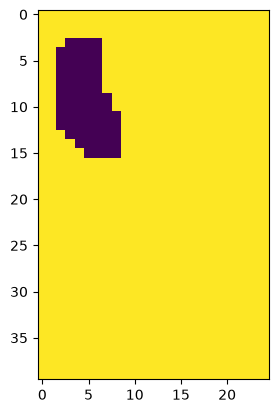

In [40]:
lake_botm = -5
gdflake = gpd.read_file(lake_file)

gix = GridIntersect(fake_grid)
cellids = gix.intersect(gdflake.geometry.values[0], contains_centroid=True)["cellids"]

idomain = np.ones((nlay, nrow, ncol), dtype=int)
for lay in range(nlay):
    for r, c in cellids:
        if botm[lay, r, c] >= lake_botm:
            idomain[lay, r, c] = 0

In [46]:
# construct the DIS package
dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    top=top,
    botm=botm,
    idomain=idomain,
    xorigin=xmin,
    yorigin=ymin
)

In [47]:
modelgrid = gwf.modelgrid

#### Construct a Node Property Flow package

The Node Property flow package stores hydraulic parameters for the model. In this example, hydraulic conductivity estimates for the model have already been produced and are stored as raster data. You'll need to resample this data to grid scale and then build a `flopy.mf6.ModflowGwfnpf` package.

The horizontal hydraulic conductivity estimates are provided below. Vertical conductivity is not known, but is generally less than horizontal hydraulic conductivity. You will need to calculate the `k33` values by using a scale factor(s) and the horizontal hydraulic conductivity values `k`.

In [48]:
hk_files = [data_ws / f"hk_{i}.tif" for i in range(1, nlay + 1)]
hk = np.zeros((nlay, nrow, ncol))
for ix, f in enumerate(hk_files):
    rstr = Raster.load(f)
    arr = rstr.resample_to_grid(modelgrid, 1, method="linear")
    hk[ix] = arr


C:\Users\jlarsen\Documents\Anaconda\envs\cwemf-modflow\Lib\site-packages\flopy\utils\rasters.py:588: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data.shape = data_shape
C:\Users\jlarsen\Documents\Anaconda\envs\cwemf-modflow\Lib\site-packages\flopy\utils\rasters.py:588: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data.shape = data_shape
C:\Users\jlarsen\Documents\Anaconda\envs\cwemf-modflow\Lib\site-packages\flopy\utils\rasters.py:588: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data.shape = data_shape
C:\Users\jlarsen\Documents\Anaconda\envs\cwemf-modflow\Lib\site-packages\flopy\

In [50]:
vk = hk * 0.01

In [51]:
npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    k=hk,
    k33=vk
)

#### Build and initial conditions package

The initial conditions package allows users to specify the starting heads of a MODFLOW model. Using the water table information provided to you in this exercise, decide on a single starting head value for the basin and set that value to the `strt` parameter.

The initial conditions package can be built using the `flopy.mf6.ModflowGwfic()` object

In [5]:
ic = flopy.mf6.ModflowGwfic(
    gwf,
    strt=14
)

#### Create a representation of the Lake

The lake can be simulated in a few different ways and each method has its own benefit and limitations.

Some options for simulating the lake are as:
   - a general head boundary where the boundary head `bhead` parameter is the lake stage and the conductance of the lake defines the rate of exchange between the Lake and groundwater system (`flopy.mf6.ModflowGwfghb`)
   - a constant head boundary where lake cell heads are set to the stage level (`flopy.mf6.ModflowGwfchd`)
   - a free surface boundary condition where the hydraulic conductivity of the lake cells is set to a very high conductivity value and the model is calibrated to keep the lake around the stage level (adjust the `hk` array
   - **Advanced usage**: would be using the lake package, but this is beyond the scope of this workshop

*Hint: no matter what your representation of the lake, the MODFLOW-IO guide can help guide what parameters you need to add/adjust in your model [MODFLOW 6 user guide](https://modflow6.readthedocs.io/en/latest/mf6io.html#groundwater-flow)*

*Hint2: the geospatial and temporal workflows and the introduction to FloPy notebooks show how to build a boundary condition package*

In [52]:
lake_file = data_ws / "lake_harbaugh.shp"
gdflake = gpd.read_file(lake_file)

In [55]:
gix = GridIntersect(modelgrid)
cellids = gix.intersect(gdflake.geometry.values[0], contains_centroid=True)["cellids"]

C:\Users\jlarsen\Documents\Anaconda\envs\cwemf-modflow\Lib\site-packages\flopy\utils\gridintersect.py:292: DeprecationWarning: In the future this function will return a GeoDataFrame by default. Set geo_dataframe=True to adopt future behavior and silence this warning. Set geo_dataframe=False to silence this warning and maintain old behavior
  warnings.warn(


In [56]:
# for GHB
# -------
records = []
for r, c in cellids:
    rec = ((1, r, c), 11, 1 * dx * dy)  # cellid, bhead, conductance
    records.append(rec)

ghb = flopy.mf6.ModflowGwfghb(
    gwf,
    stress_period_data={0: records}
)

In [ ]:
# for CHD
# -------
# records = []
# for r, c in cellids:
#     rec = ((1, r, c), 11)  # cellid, head
#     records.append(rec)

# ghb = flopy.mf6.ModflowGwfchd(
#     gwf,
#     stress_period_data={0: records}
# )

In [ ]:
# for high K (free surface bc)
# ----------------------------
# idomain = dis.idomain.array
# idomain[:, :, :] = 1
# hk = npf.k.array
# for r, c in cellids:
#     hk[0, r, c] = 10000

# dis.idomain.set_data(idomain)
# npf.k.set_data(hk)

#### Create a River package that represents straight river

The river package simulates exchange between the groundwater system and rivers. This package is a head dependendent flux boundary condition and is similar to (but slightly different than) the general head boundary condition package. Using the information provided in the description of the basin, create a river package using `flopy.mf6.ModflowGwfriv()`

*Hint: inputs needed for the River package can be found in the [MODFLOW 6 user guide](https://modflow6.readthedocs.io/en/latest/mf6io.html#groundwater-flow)*

*Hint2: we created a RIV package in the introduction to flopy notebook*

*Hint3: adding `print_flows=True` as a parameter in the `flopy.mf6.ModflowGwfriv()` package will print flows by cell to the list file*

In [59]:
river_file = data_ws / "straight_river.shp"
gdfriv = gpd.read_file(river_file)
gdfriv

,Id,geometry
0,0,"LINESTRING (4278.242 9003.686, 4203.708 -14.907)"


In [61]:
gix = GridIntersect(modelgrid)
cellids = gix.intersect(gdfriv.geometry.values[0])["cellids"]

[(np.int64(21), np.int64(8)), (np.int64(22), np.int64(8)), (np.int64(23), np.int64(8)), (np.int64(24), np.int64(8)), (np.int64(25), np.int64(8)), (np.int64(26), np.int64(8)), (np.int64(27), np.int64(8)), (np.int64(28), np.int64(8)), (np.int64(29), np.int64(8)), (np.int64(30), np.int64(8)), (np.int64(31), np.int64(8)), (np.int64(32), np.int64(8)), (np.int64(33), np.int64(8)), (np.int64(34), np.int64(8)), (np.int64(35), np.int64(8)), (np.int64(36), np.int64(8)), (np.int64(37), np.int64(8)), (np.int64(38), np.int64(8)), (np.int64(39), np.int64(8))]


C:\Users\jlarsen\Documents\Anaconda\envs\cwemf-modflow\Lib\site-packages\flopy\utils\gridintersect.py:292: DeprecationWarning: In the future this function will return a GeoDataFrame by default. Set geo_dataframe=True to adopt future behavior and silence this warning. Set geo_dataframe=False to silence this warning and maintain old behavior
  warnings.warn(


In [63]:
# interpolate the stages
top_stage = 1.8
out_stage = 0
stage = np.linspace(top_stage, out_stage, len(cellids))
riv_bed = stage - 1

In [ ]:
records = []
for ix, (r, c) in enumerate(cellids):
    rec = ((0, r, c), stage[ix], 100 * dy * 1, riv_bed[ix])  # cellid, stage, cond, rbot
    records.append(rec)


In [ ]:
riv = flopy.mf6.ModflowGwfriv(
    gwf,
    print_flows=True,
    stress_period_data=records
)

#### Output control

The output control package is used to control head and budget outputs from MODFLOW. 